<h1 style="text-align:center;">Integrate experimental X-scan data with AF3 PAE</h1>

In [2]:
import json
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


# Predict experimentally tested models

In [92]:
# predict experimentally tested models

dico = [
    {'id': 'TCR_YF1', 'TRAV':'TRAV12-2', 'TRAJ':'TRAJ30', 'cdr3_TRA':'CAVGDDKIIF', 'TRBV':'TRBV28', 'TRBJ':'TRBJ2-7', 'cdr3_TRB':'CASTPQTAYEQYF'},
    {'id': 'TCR_YF2', 'TRAV':'TRAV12-2', 'TRAJ':'TRAJ30', 'cdr3_TRA':'CAVNPDKIIF', 'TRBV':'TRBV4-2', 'TRBJ':'TRBJ1-4', 'cdr3_TRB':'CASSQEDRGPEKLFF'},
    {'id': 'TCR_YF3', 'TRAV':'TRAV12-2', 'TRAJ':'TRAJ30', 'cdr3_TRA':'CAAGDDKIIF', 'TRBV':'TRBV29-1', 'TRBJ':'TRBJ2-1', 'cdr3_TRB':'CSVATSGGSNEQFF'}
]

df = pd.DataFrame(dico)
df['peptide'] = 'LLWNGPMAV'
df['MHC'] = 'HLA_A0201'
df['species'] = 'HomoSapiens'

df.to_csv('Xscan_models_LLWNGPMAV.csv', index=False)
df

,id,TRAV,TRAJ,cdr3_TRA,TRBV,TRBJ,cdr3_TRB,peptide,MHC,species
0,TCR_YF1,TRAV12-2,TRAJ30,CAVGDDKIIF,TRBV28,TRBJ2-7,CASTPQTAYEQYF,LLWNGPMAV,HLA_A0201,HomoSapiens
1,TCR_YF2,TRAV12-2,TRAJ30,CAVNPDKIIF,TRBV4-2,TRBJ1-4,CASSQEDRGPEKLFF,LLWNGPMAV,HLA_A0201,HomoSapiens
2,TCR_YF3,TRAV12-2,TRAJ30,CAAGDDKIIF,TRBV29-1,TRBJ2-1,CSVATSGGSNEQFF,LLWNGPMAV,HLA_A0201,HomoSapiens


# Extract peptide PAE

In [7]:
def get_chain_segments(chain_ids):
    boundaries = []
    chain_labels = []
    start = 0

    for i in range(1, len(chain_ids)):
        if chain_ids[i] != chain_ids[i - 1]:
            boundaries.append(i)
            chain_labels.append((start, i, chain_ids[i - 1]))
            start = i
    chain_labels.append((start, len(chain_ids), chain_ids[-1]))
    return boundaries, chain_labels


def select_chain_positions(chain_ids, chain_id, ranges):
    """
    Select residues from one chain using 1-based inclusive ranges
    within that chain's sequence order.
    """
    idx_chain = np.where(chain_ids == chain_id)[0]
    pos_chain = np.arange(1, len(idx_chain) + 1)

    selected = []
    for start, end in ranges:
        idx_range = idx_chain[(pos_chain >= start) & (pos_chain <= end)]
        selected.append(idx_range)

    if len(selected) == 0:
        return np.array([], dtype=int)

    return np.concatenate(selected)


def compute_mean_peptide_pae_to_interface(
    json_file,
    mhc_groove_ranges,
    loops_A=None,
    loops_B=None,
    peptide_chain="C",
    tcra_chain="A",
    tcrb_chain="B",
    mhc_chain="D",
    pae_cutoff=10,
    plot=False,
    use_full_tcr=False,
):
    """
    For each peptide residue (chain C), compute mean PAE over rows from:
    - selected MHC groove residues (chain D)
    - plus either:
        * selected TCR loop residues (chains A and B), or
        * the full TCR alpha and beta chains

    Parameters
    ----------
    use_full_tcr : bool
        If True, use all residues from chains A and B.
        If False, use only loops_A and loops_B.
    """

    with open(json_file, "r") as f:
        data = json.load(f)

    pae = np.array(data["pae"])
    chain_ids = np.array(data["token_chain_ids"])

    if plot:
        boundaries, chain_labels = get_chain_segments(chain_ids)

        plt.figure(figsize=(4, 3.5))
        im = plt.imshow(pae, origin="upper", interpolation="nearest", vmin=0, vmax=30)
        plt.colorbar(im, label="PAE (Å)")
        plt.xlabel("Residue index")
        plt.ylabel("Residue index")

        for b in boundaries:
            plt.axhline(b - 0.5, linewidth=1, color="black")
            plt.axvline(b - 0.5, linewidth=1, color="black")

        tick_positions = []
        tick_labels = []
        for s, e, cid in chain_labels:
            tick_positions.append((s + e - 1) / 2)
            tick_labels.append(str(cid))

        plt.xticks(tick_positions, tick_labels)
        plt.yticks(tick_positions, tick_labels)
        plt.tight_layout()
        plt.show()

    idx_pep = np.where(chain_ids == peptide_chain)[0]
    idx_mhc_groove = select_chain_positions(chain_ids, mhc_chain, mhc_groove_ranges)

    if use_full_tcr:
        idx_tcr_A = np.where(chain_ids == tcra_chain)[0]
        idx_tcr_B = np.where(chain_ids == tcrb_chain)[0]
    else:
        if loops_A is None or loops_B is None:
            raise ValueError("loops_A and loops_B must be provided when use_full_tcr=False")

        idx_tcr_A = select_chain_positions(chain_ids, tcra_chain, loops_A)
        idx_tcr_B = select_chain_positions(chain_ids, tcrb_chain, loops_B)

    idx_rows = np.concatenate([idx_mhc_groove, idx_tcr_A, idx_tcr_B])

    sub_pae = pae[np.ix_(idx_rows, idx_pep)].copy()
    sub_pae[sub_pae > pae_cutoff] = np.nan

    peptide_positions = np.arange(1, len(idx_pep) + 1)

    df = pd.DataFrame({
        "Position": peptide_positions,
        "pae_col": np.nanmean(sub_pae, axis=0),
    })

    return df

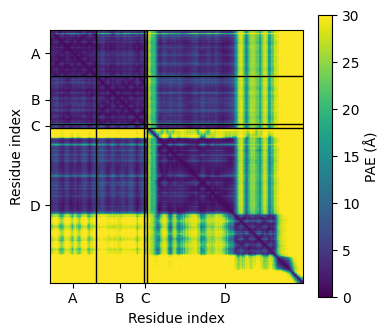

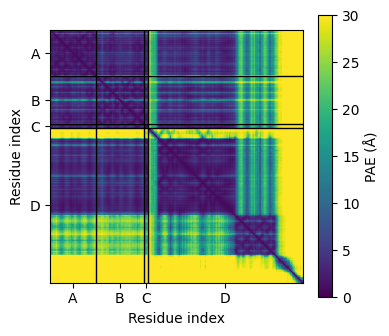

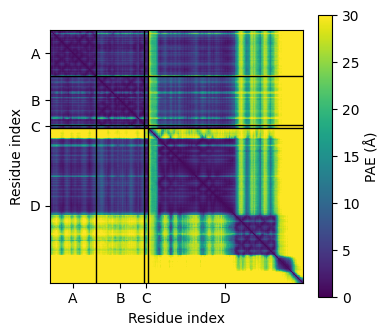

,Position,pae_col,TCR
0,1,3.328010,TCR_YF1
1,2,3.111749,TCR_YF1
2,3,3.007592,TCR_YF1
3,4,2.928721,TCR_YF1
4,5,2.917060,TCR_YF1
5,6,3.020104,TCR_YF1
6,7,3.076378,TCR_YF1
7,8,3.281250,TCR_YF1
8,9,3.493717,TCR_YF1
9,1,3.123404,TCR_YF2


In [61]:
system = 'LLWNGPMAV'
mhc_groove_ranges = [
    (26, 200)
]

lst = []
for i in range(3):
    df = compute_mean_peptide_pae_to_interface(
        json_file=f"AF3_output_{system}/tcr_yf{i+1}/fold_tcr_yf{i+1}_full_data_0.json",
        mhc_groove_ranges=mhc_groove_ranges,
        use_full_tcr=True,
        plot=True,
    )

    df['TCR'] = f'TCR_YF{i+1}'
    lst.append(df)

df = pd.concat(lst, ignore_index=True)
df.to_pickle(f'mean_pae_{system}.pkl')
df

ActivationScore: Spearman rho = 0.73, p = 0.0246
ActivationScore: Spearman rho = 0.68, p = 0.0424
ActivationScore: Spearman rho = 0.66, p = 0.0525


Text(0, 0.5, 'TCR Activation [%]')

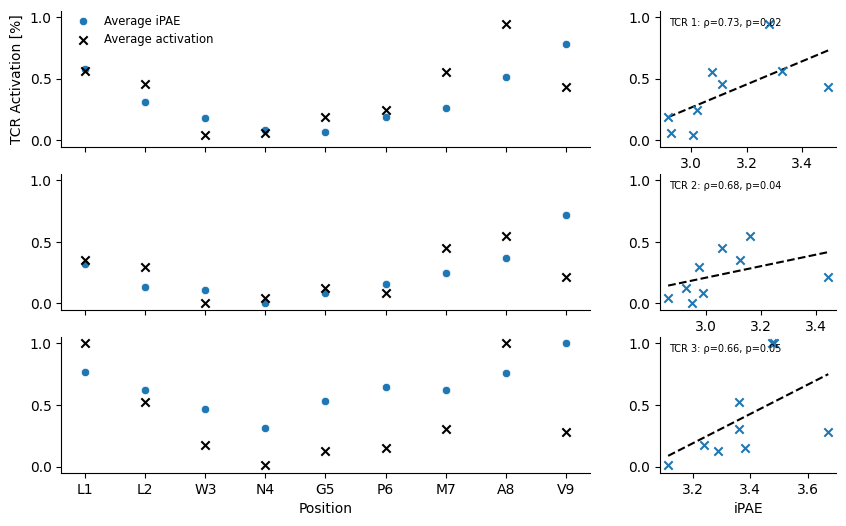

In [ ]:
sequence = 'LLWNGPMAV'
df_activation = pd.read_pickle('../260317_YF-modes_exp_integration_clean/activation_scores.pkl')[['Position', 'TCR', 'ActivationScore']]
df_activation['ActivationScore'] = df_activation['ActivationScore']/100
df_activation = (df_activation
        .groupby(['Position', 'TCR'], as_index=False)['ActivationScore']
        .mean())
df_activation['ActivationScore'] = df_activation['ActivationScore'].clip(0, 1)

df_pae = pd.read_pickle(f'mean_pae_{sequence}.pkl')
col = df_pae['pae_col']
df_pae['pae_col_scaled'] = (col - col.min()) / (col.max() - col.min()) # scale between 0 and 1

df = pd.merge(df_activation, df_pae, on=['Position', 'TCR'])

fig, axes = plt.subplots(3, 2, figsize=(10, 6), sharey=False, gridspec_kw={'width_ratios': [3, 1]})

for i in range(3):
    tmp = df[df['TCR'] == f'TCR_YF{i+1}']

    # scatter plot
    ax = axes[i][0]
    sns.scatterplot(data=tmp, x='Position', y='pae_col_scaled', ax=ax, label='Average iPAE')
    sns.scatterplot(data=tmp, x='Position', y='ActivationScore', ax=ax, label='Average activation', marker='x', color='black', linewidth=1.5)
    ax.legend([], [], frameon=False)
    ax.set_ylabel(f'TCR {i+1} [%]')
    ax.set_ylim(-0.05,1.05)
    ax.set_xticklabels('')
    ax.set_ylabel('')

    # correlation plot
    ax = axes[i][1]

    # Compute Spearman correlation
    tmp = tmp.dropna()
    rho, pval = spearmanr(tmp['pae_col'], tmp['ActivationScore'])
    print(f"ActivationScore: Spearman rho = {rho:.2f}, p = {pval:.3g}")

    # Draw a smooth line showing monotonic trend
    sns.regplot(x=tmp['pae_col'], y=tmp['ActivationScore'], ax=ax, scatter=False, color='black', line_kws={'lw':1.5, 'ls':'--'}, ci=False)

    # Add rho to the plot
    # Format string
    if pval < 0.01:
        p_str = f"{pval:.1e}"   # scientific notation
    else:
        p_str = f"{pval:.2f}"   # fixed-point

    ax.text(
    0.05, 0.95, f"TCR {i+1}: ρ={rho:.2f}, p={p_str}", 
    transform=ax.transAxes, fontsize=7, verticalalignment='top'
    )

    df_avg = (tmp.groupby(['Position', 'pae_col'], as_index=False)['ActivationScore'].mean())
    sns.scatterplot(df_avg, x='pae_col', y='ActivationScore', ax=ax, legend=False, marker='x', linewidth=1.5, zorder=2)

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(-0.05,1.05)
    sns.despine()



axes[0][0].legend(bbox_to_anchor=(0,1.05), frameon=False, title='', loc='upper left', fontsize='small')

sequence = 'LLWNGPMAV'
new_labels = [f'{sequence[i]}{i+1}' for i in range(9)]
axes[2][0].set_xticks(range(1, len(new_labels)+1))
axes[2][0].set_xticklabels(new_labels)

axes[0][0].set_xlabel('')
axes[1][0].set_xlabel('')
axes[2][0].set_xlabel('Position')
axes[2][1].set_xlabel('iPAE')

axes[0][0].set_ylabel('TCR Activation [%]')



# B0801_RAKFKQLL

In [ ]:
c

,id,TRAV,TRAJ,TRBV,TRBJ,cdr3_TRA,cdr3_TRB,peptide,species,MHC
37637,tcr_0001,TRAV13-1,TRAJ50,TRBV7-9,TRBJ1-1,CAASETSYDKVIF,CASSLLGQKDTEAFF,RAKFKQLL,HomoSapiens,HLA_B0801


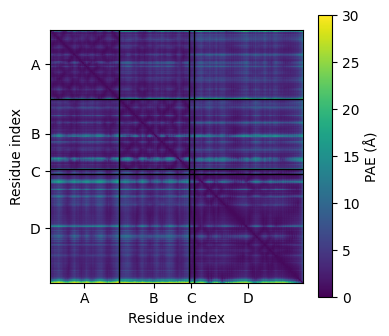

,Position,pae_col
0,1,3.470652
1,2,3.362398
2,3,3.270190
3,4,3.052703
4,5,3.264674
5,6,3.220163
6,7,3.213388
7,8,3.441484


In [42]:
plot = True
system = 'RAKFKQLL'

json_file = f"AF3_output_{system}/fold_rakfkqll/fold_rakfkqll_full_data_0.json"

mhc_groove_ranges = [
    (26, 200)
]

# consider full tcr
loops_A = [(1, 110)]
loops_B = [(1, 100)]


df = compute_mean_peptide_pae_to_interface(
    json_file=json_file,
    mhc_groove_ranges=mhc_groove_ranges,
    use_full_tcr=True,
    plot=True,
)

df.to_pickle(f'mean_pae_{system}.pkl')
df

ActivationScore: Spearman rho = 0.21, p = 0.61


Text(0, 0.5, 'TCR Activation [%]')

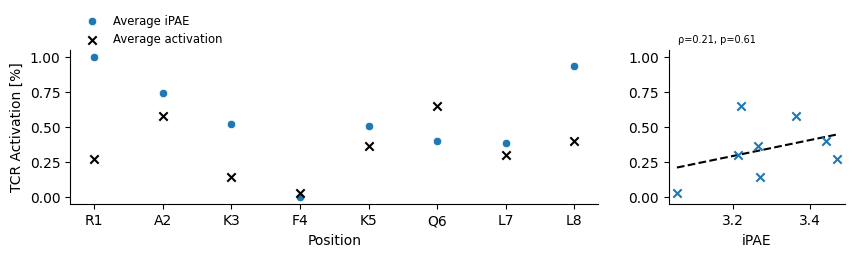

In [52]:
sequence = 'RAKFKQLL'

# activation scores
df_activation = pd.read_csv('../260303_B0801_RAKFKQLL/RAK_Xscan.csv', sep=';')
df_activation['Position'] = df_activation['Position'].str[-1].astype(int)
df_activation['ActivationScore'] =  df_activation['ActivationScore'].astype(float)
df_activation['ActivationScore'] = df_activation['ActivationScore']/100
df_activation = (df_activation
        .groupby(['Position'], as_index=False)['ActivationScore']
        .mean())
df_activation['ActivationScore'] = df_activation['ActivationScore'].clip(0, 1)

df_pae = pd.read_pickle(f'mean_pae_{sequence}.pkl')
col = df_pae['pae_col']
df_pae['pae_col_scaled'] = (col - col.min()) / (col.max() - col.min()) # scale between 0 and 1

df = pd.merge(df_activation, df_pae, on=['Position'])

fig, axes = plt.subplots(1, 2, figsize=(10, 2), sharey=False, gridspec_kw={'width_ratios': [3, 1]})

# scatter plot
ax = axes[0]
sns.scatterplot(data=df, x='Position', y='pae_col_scaled', ax=ax, label='Average iPAE')
sns.scatterplot(data=df, x='Position', y='ActivationScore', ax=ax, label='Average activation', marker='x', color='black', linewidth=1.5)
ax.legend([], [], frameon=False)
ax.set_ylabel(f'TCR [%]')
ax.set_ylim(-0.05,1.05)
ax.set_xticklabels('')
ax.set_ylabel('')

# correlation plot
ax = axes[1]

# Compute Spearman correlation
df = df.dropna()
rho, pval = spearmanr(df['pae_col'], df['ActivationScore'])
print(f"ActivationScore: Spearman rho = {rho:.2f}, p = {pval:.3g}")

# Draw a smooth line showing monotonic trend
sns.regplot(x=df['pae_col'], y=df['ActivationScore'], ax=ax, scatter=False, color='black', line_kws={'lw':1.5, 'ls':'--'}, ci=False)

# Add rho to the plot
# Format string
if pval < 0.01:
    p_str = f"{pval:.1e}"   # scientific notation
else:
    p_str = f"{pval:.2f}"   # fixed-point

ax.text(
0.05, 1.1, f"ρ={rho:.2f}, p={p_str}", 
transform=ax.transAxes, fontsize=7, verticalalignment='top'
)

df_avg = (df.groupby(['Position', 'pae_col'], as_index=False)['ActivationScore'].mean())
sns.scatterplot(df_avg, x='pae_col', y='ActivationScore', ax=ax, legend=False, marker='x', linewidth=1.5, zorder=2)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_ylim(-0.05,1.05)
sns.despine()


axes[0].legend(bbox_to_anchor=(0,1.3), frameon=False, title='', loc='upper left', fontsize='small')

new_labels = [f'{sequence[i]}{i+1}' for i in range(len(sequence))]
axes[0].set_xticks(range(1, len(new_labels)+1))
axes[0].set_xticklabels(new_labels)

axes[0].set_xlabel('Position')
axes[1].set_xlabel('iPAE')

axes[0].set_ylabel('TCR Activation [%]')

# Correlation with weighted X-scan matrix

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_13323/282000263.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


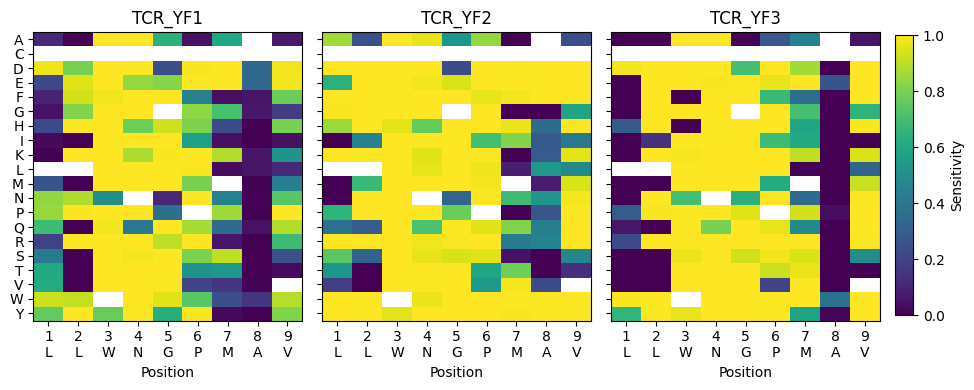

,TCR,Position,Sensitivity,Activation
0,TCR_YF1,1,0.435989,0.564011
1,TCR_YF1,2,0.570883,0.429117
2,TCR_YF1,3,0.957000,0.043000
3,TCR_YF1,4,0.936750,0.063250
4,TCR_YF1,5,0.809394,0.190606


In [82]:
sequence = 'LLWNGPMAV'
df_activation = pd.read_pickle('../260317_YF-modes_exp_integration_clean/activation_scores.pkl')[['Position', 'Aa', 'Aa_WT', 'ActivationScore', 'TCR']]
df_activation['ActivationScore'] = df_activation['ActivationScore']/100
df_activation['ActivationScore'] = df_activation['ActivationScore'].clip(0, 1)
df_activation['SensitivityScore'] = 1 - df_activation['ActivationScore'] 

# fixed AA order for rows
aa_order = list("ACDEFGHIKLMNPQRSTVWY")

tcrs = sorted(df_activation['TCR'].unique())
fig, axes = plt.subplots(1, len(tcrs), figsize=(3 * len(tcrs), 4), sharey=True)

if len(tcrs) == 1:
    axes = [axes]

for ax, (name, group) in zip(axes, df_activation.groupby('TCR')):
    heatmap_df = group.pivot_table(
        index='Aa',
        columns='Position',
        values='SensitivityScore',
        aggfunc='mean'
    )

    # enforce row and column order
    heatmap_df = heatmap_df.reindex(index=aa_order)
    heatmap_df = heatmap_df.reindex(columns=range(1, len(sequence) + 1))

    im = ax.imshow(
        heatmap_df.values,
        aspect='auto',
        origin='upper',
        vmin=0,
        vmax=1
    )

    ax.set_title(name)
    ax.set_xlabel('Position')
    ax.set_xticks(np.arange(len(sequence)))
    ax.set_xticklabels([f"{i+1}\n{aa}" for i, aa in enumerate(sequence)])

    ax.set_yticks(np.arange(len(aa_order)))
    ax.set_yticklabels(aa_order)

# one shared colorbar
cax = fig.add_axes([1.0, 0.2, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, shrink=0.8)
cbar.set_label('Sensitivity')

plt.tight_layout()
plt.show()

df = (
    df_activation
    .groupby(['TCR', 'Position'], as_index=False)[['SensitivityScore', 'ActivationScore']]
    .mean()
)

df = df.rename(columns={'SensitivityScore': 'Sensitivity', 'ActivationScore': 'Activation'})
df.to_pickle(f'mean_sensitivity_{sequence}.pkl')
df.head()

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_13323/2179628689.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


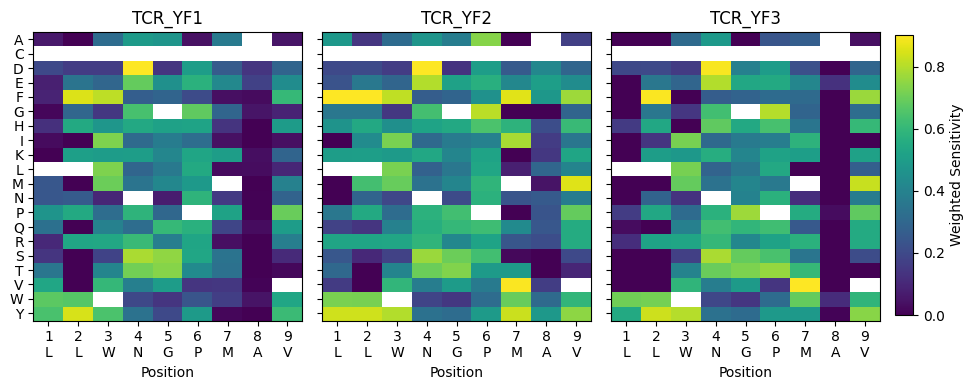

In [94]:
# --- sequence ---
sequence = 'LLWNGPMAV'

# --- load data ---
df_activation = pd.read_pickle(
    '../260317_YF-modes_exp_integration_clean/activation_scores.pkl'
)[['Position', 'Aa', 'Aa_WT', 'ActivationScore', 'TCR']].copy()

# --- normalize activation ---
df_activation['ActivationScore'] = df_activation['ActivationScore'] / 100
df_activation['ActivationScore'] = df_activation['ActivationScore'].clip(0, 1)

# --- compute sensitivity ---
df_activation['SensitivityScore'] = 1 - df_activation['ActivationScore']


# ============================================================
# 🧬 Grantham distance matrix (subset, full standard matrix)
# ============================================================

# Full Grantham matrix as dict
# (symmetric, so we fill both directions)
grantham_matrix = {
('A','A'):0,('A','R'):112,('A','N'):111,('A','D'):126,('A','C'):195,('A','Q'):91,('A','E'):107,('A','G'):60,('A','H'):86,('A','I'):94,('A','L'):96,('A','K'):106,('A','M'):84,('A','F'):113,('A','P'):27,('A','S'):99,('A','T'):58,('A','W'):148,('A','Y'):112,('A','V'):64,
('R','N'):86,('R','D'):96,('R','C'):180,('R','Q'):43,('R','E'):54,('R','G'):125,('R','H'):29,('R','I'):97,('R','L'):102,('R','K'):26,('R','M'):91,('R','F'):97,('R','P'):103,('R','S'):110,('R','T'):71,('R','W'):101,('R','Y'):77,('R','V'):96,
('N','D'):23,('N','C'):139,('N','Q'):46,('N','E'):42,('N','G'):80,('N','H'):68,('N','I'):149,('N','L'):153,('N','K'):94,('N','M'):142,('N','F'):158,('N','P'):91,('N','S'):46,('N','T'):65,('N','W'):174,('N','Y'):143,('N','V'):133,
('D','C'):154,('D','Q'):61,('D','E'):45,('D','G'):94,('D','H'):81,('D','I'):168,('D','L'):172,('D','K'):101,('D','M'):160,('D','F'):177,('D','P'):108,('D','S'):65,('D','T'):85,('D','W'):181,('D','Y'):160,('D','V'):152,
('C','Q'):154,('C','E'):170,('C','G'):159,('C','H'):174,('C','I'):198,('C','L'):198,('C','K'):202,('C','M'):196,('C','F'):205,('C','P'):169,('C','S'):112,('C','T'):149,('C','W'):215,('C','Y'):194,('C','V'):192,
('Q','E'):29,('Q','G'):87,('Q','H'):24,('Q','I'):109,('Q','L'):113,('Q','K'):53,('Q','M'):101,('Q','F'):116,('Q','P'):76,('Q','S'):68,('Q','T'):42,('Q','W'):130,('Q','Y'):99,('Q','V'):96,
('E','G'):98,('E','H'):40,('E','I'):134,('E','L'):138,('E','K'):56,('E','M'):126,('E','F'):140,('E','P'):93,('E','S'):80,('E','T'):65,('E','W'):152,('E','Y'):122,('E','V'):121,
('G','H'):98,('G','I'):135,('G','L'):138,('G','K'):127,('G','M'):127,('G','F'):153,('G','P'):42,('G','S'):56,('G','T'):59,('G','W'):184,('G','Y'):147,('G','V'):109,
('H','I'):94,('H','L'):99,('H','K'):32,('H','M'):87,('H','F'):100,('H','P'):77,('H','S'):89,('H','T'):47,('H','W'):115,('H','Y'):83,('H','V'):84,
('I','L'):5,('I','K'):102,('I','M'):10,('I','F'):21,('I','P'):95,('I','S'):142,('I','T'):89,('I','W'):61,('I','Y'):33,('I','V'):29,
('L','K'):107,('L','M'):15,('L','F'):22,('L','P'):98,('L','S'):145,('L','T'):92,('L','W'):61,('L','Y'):36,('L','V'):32,
('K','M'):95,('K','F'):102,('K','P'):103,('K','S'):121,('K','T'):78,('K','W'):110,('K','Y'):85,('K','V'):97,
('M','F'):28,('M','P'):87,('M','S'):135,('M','T'):81,('M','W'):67,('M','Y'):36,('M','V'):21,
('F','P'):114,('F','S'):155,('F','T'):103,('F','W'):40,('F','Y'):22,('F','V'):50,
('P','S'):74,('P','T'):38,('P','W'):147,('P','Y'):110,('P','V'):68,
('S','T'):58,('S','W'):177,('S','Y'):144,('S','V'):124,
('T','W'):128,('T','Y'):92,('T','V'):69,
('W','Y'):37,('W','V'):88,
('Y','V'):55
}

# make symmetric
for (a, b), v in list(grantham_matrix.items()):
    grantham_matrix[(b, a)] = v


# --- compute Grantham distances ---
df_activation['GranthamDist'] = df_activation.apply(
    lambda x: grantham_matrix.get((x['Aa_WT'], x['Aa']), 0),
    axis=1
)

# --- convert to similarity weight (0–1) ---
MAX_GRANTHAM = 215
df_activation['Weight'] = 1 - (df_activation['GranthamDist'] / MAX_GRANTHAM)

# --- weighted sensitivity ---
df_activation['WeightedSensitivity'] = (
    df_activation['SensitivityScore'] * df_activation['Weight']
)

# ============================================================
# 🔥 Plot heatmaps
# ============================================================

aa_order = list("ACDEFGHIKLMNPQRSTVWY")
tcrs = sorted(df_activation['TCR'].unique())

fig, axes = plt.subplots(1, len(tcrs), figsize=(3 * len(tcrs), 4), sharey=True)

if len(tcrs) == 1:
    axes = [axes]

for ax, (name, group) in zip(axes, df_activation.groupby('TCR')):

    heatmap_df = group.pivot_table(
        index='Aa',
        columns='Position',
        values='WeightedSensitivity',
        aggfunc='mean'
    )

    heatmap_df = heatmap_df.reindex(index=aa_order)
    heatmap_df = heatmap_df.reindex(columns=range(1, len(sequence) + 1))

    im = ax.imshow(
        heatmap_df.values,
        aspect='auto',
        origin='upper'
    )

    ax.set_title(name)
    ax.set_xlabel('Position')

    ax.set_xticks(np.arange(len(sequence)))
    ax.set_xticklabels([f"{i+1}\n{aa}" for i, aa in enumerate(sequence)])

    ax.set_yticks(np.arange(len(aa_order)))
    ax.set_yticklabels(aa_order)

# --- colorbar ---
cax = fig.add_axes([1.0, 0.2, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Weighted Sensitivity')

plt.tight_layout()
plt.show()

df = (
    df_activation
    .groupby(['TCR', 'Position'], as_index=False)[['WeightedSensitivity']]
    .mean()
)
df = df.rename(columns={'WeightedSensitivity': 'Weighted Sensitivity'})
df.to_pickle(f'mean_weighted_sensitivity_{sequence}.pkl')

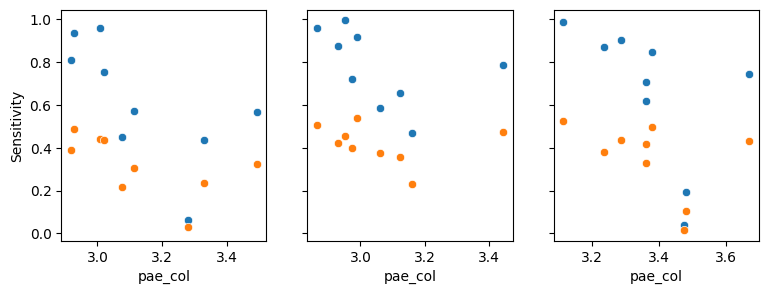

In [ ]:
system = 'LLWNGPMAV'
df1 = pd.read_pickle(f'mean_pae_{system}.pkl')
df2 = pd.read_pickle(f'mean_sensitivity_{system}.pkl')
df3 = pd.read_pickle(f'mean_weighted_sensitivity_{system}.pkl')

df = pd.merge(df1, df2, on=['Position', 'TCR'])
df = pd.merge(df, df3, on=['Position', 'TCR'])


fig, axes = plt.subplots(1,3,figsize=(9,3), sharey=True)

for cnt, (name, group) in enumerate(df.groupby('TCR')):
    ax = axes[cnt]


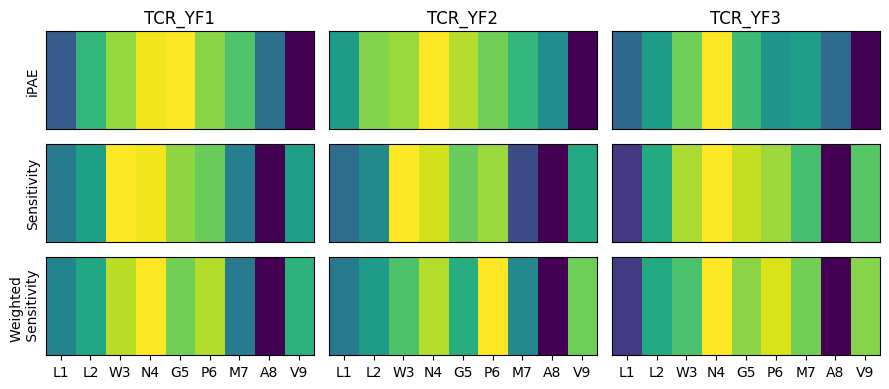

,TCR,PAE_vs_Sensitivity,PAE_vs_WeightedSensitivity
0,TCR_YF1,-0.648987,-0.574736
1,TCR_YF2,-0.445753,-0.243025
2,TCR_YF3,-0.529762,-0.413473


In [80]:
system = 'LLWNGPMAV'

df1 = pd.read_pickle(f'mean_pae_{system}.pkl')
df2 = pd.read_pickle(f'mean_sensitivity_{system}.pkl')
df3 = pd.read_pickle(f'mean_weighted_sensitivity_{system}.pkl')

df = pd.merge(df1, df2, on=['Position', 'TCR'])
df = pd.merge(df, df3, on=['Position', 'TCR'])

tcrs = sorted(df['TCR'].unique())
n_pos = len(system)

fig = plt.figure(figsize=(3 * len(tcrs), 4))

for col, (name, group) in enumerate(df.groupby('TCR')):
    group = group.sort_values('Position')

    # extract vectors
    pae = group['pae_col'].values[np.newaxis, :]
    sens = group['Sensitivity'].values[np.newaxis, :]
    wsens = group['Weighted Sensitivity'].values[np.newaxis, :]

    # --- create 3 stacked axes per TCR ---
    ax1 = fig.add_subplot(3, len(tcrs), col + 1)
    ax2 = fig.add_subplot(3, len(tcrs), col + 1 + len(tcrs))
    ax3 = fig.add_subplot(3, len(tcrs), col + 1 + 2*len(tcrs))

    # --- plot each with its own scale ---
    im1 = ax1.imshow(pae, aspect='auto', origin='upper',
                     vmin=np.nanmin(pae), vmax=np.nanmax(pae), cmap='viridis_r')
    im2 = ax2.imshow(sens, aspect='auto', origin='upper',
                     vmin=np.nanmin(sens), vmax=np.nanmax(sens))
    im3 = ax3.imshow(wsens, aspect='auto', origin='upper',
                     vmin=np.nanmin(wsens), vmax=np.nanmax(wsens))

    # titles
    ax1.set_title(name)

    # y labels only on first column
    if col == 0:
        ax1.set_ylabel('iPAE')
        ax2.set_ylabel('Sensitivity')
        ax3.set_ylabel('Weighted \n Sensitivity')

    # x axis only on bottom row
    for ax in [ax1, ax2]:
        ax.set_xticks([])

    ax3.set_xticks(np.arange(n_pos))
    ax3.set_xticklabels([f"{system[i]}{i+1}" for i in range(n_pos)])

    # remove y ticks
    for ax in [ax1, ax2, ax3]:
        ax.set_yticks([])

plt.tight_layout()
plt.show()

# compute correlations
results = []

for name, group in df.groupby('TCR'):
    group = group.sort_values('Position')

    pae = group['pae_col']
    sens = group['Sensitivity']
    wsens = group['Weighted Sensitivity']

    corr_sens = pae.corr(sens)
    corr_wsens = pae.corr(wsens)

    results.append({
        'TCR': name,
        'PAE_vs_Sensitivity': corr_sens,
        'PAE_vs_WeightedSensitivity': corr_wsens
    })

df_corr = pd.DataFrame(results)
df_corr

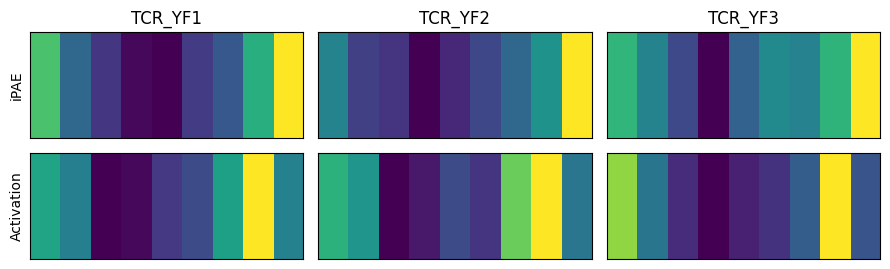

,TCR,PAE_vs_Activation
0,TCR_YF1,0.648987
1,TCR_YF2,0.445753
2,TCR_YF3,0.529762


In [92]:
system = 'LLWNGPMAV'

df1 = pd.read_pickle(f'mean_pae_{system}.pkl')
df2 = pd.read_pickle(f'mean_sensitivity_{system}.pkl')

df = pd.merge(df1, df2, on=['Position', 'TCR'])

tcrs = sorted(df['TCR'].unique())
n_pos = len(system)

fig = plt.figure(figsize=(3 * len(tcrs), 4))

for col, (name, group) in enumerate(df.groupby('TCR')):
    group = group.sort_values('Position')

    # extract vectors
    pae = group['pae_col'].values[np.newaxis, :]
    sens = group['Activation'].values[np.newaxis, :]

    # --- create 3 stacked axes per TCR ---
    ax1 = fig.add_subplot(3, len(tcrs), col + 1)
    ax2 = fig.add_subplot(3, len(tcrs), col + 1 + len(tcrs))

    # --- plot each with its own scale ---
    im1 = ax1.imshow(pae, aspect='auto', origin='upper',
                     vmin=np.nanmin(pae), vmax=np.nanmax(pae))
    im2 = ax2.imshow(sens, aspect='auto', origin='upper',
                     vmin=np.nanmin(sens), vmax=np.nanmax(sens))
    # titles
    ax1.set_title(name)

    # y labels only on first column
    if col == 0:
        ax1.set_ylabel('iPAE')
        ax2.set_ylabel('Activation')

    # x axis only on bottom row
    for ax in [ax1, ax2]:
        ax.set_xticks([])

    ax3.set_xticks(np.arange(n_pos))
    ax3.set_xticklabels([f"{system[i]}{i+1}" for i in range(n_pos)])

    # remove y ticks
    for ax in [ax1, ax2, ax3]:
        ax.set_yticks([])

plt.tight_layout()
plt.show()

# compute correlations
results = []

for name, group in df.groupby('TCR'):
    group = group.sort_values('Position')

    pae = group['pae_col']
    sens = group['Activation']

    corr_sens = pae.corr(sens)
    corr_wsens = pae.corr(wsens)

    results.append({
        'TCR': name,
        'PAE_vs_Activation': corr_sens,
    })

df_corr = pd.DataFrame(results)
df_corr

Text(0.5, 0, 'Mean iPAE [Å]')

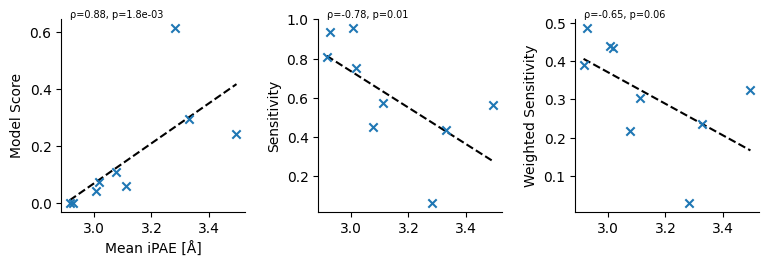

In [117]:
system = 'LLWNGPMAV'

df1 = pd.read_pickle(f'mean_pae_{system}.pkl')
df2 = pd.read_pickle(f'mean_sensitivity_{system}.pkl')
df3 = pd.read_pickle(f'mean_weighted_sensitivity_{system}.pkl')
df4 = pd.read_pickle('../260317_YF-modes_exp_integration_clean/model-score.pkl')[['Position', 'ModelScore', 'TCR']]
df4 = df4.drop_duplicates()

df = pd.merge(df1, df2, on=['Position', 'TCR'])
df = pd.merge(df, df3, on=['Position', 'TCR'])
df = pd.merge(df, df4, on=['Position', 'TCR'])

df = df[df['TCR'] == 'TCR_YF1']

fig, axes = plt.subplots(1, 3, figsize=(9,2.5))
plt.subplots_adjust(wspace=0.4)
params = ['ModelScore', 'Sensitivity', 'Weighted Sensitivity']

for cnt, param in enumerate(params):
    ax = axes[cnt]

    # Compute Spearman correlation
    rho, pval = spearmanr(df['pae_col'], df[param])

    # Draw a smooth line showing monotonic trend
    sns.regplot(x=df['pae_col'], y=df[param], ax=ax, scatter=False, color='black', line_kws={'lw':1.5, 'ls':'--'}, ci=False)

    # Add rho to the plot
    # Format string
    if pval < 0.01:
        p_str = f"{pval:.1e}"   # scientific notation
    else:
        p_str = f"{pval:.2f}"   # fixed-point

    ax.text(
    0.05, 1.05, f"ρ={rho:.2f}, p={p_str}", 
    transform=ax.transAxes, fontsize=7, verticalalignment='top'
    )

    sns.scatterplot(df, x='pae_col', y=param, ax=ax, legend=False, marker='x', linewidth=1.5, zorder=2)

    ax.set_xlabel('')
    sns.despine()

axes[0].set_ylabel('Model Score')
axes[0].set_xlabel('Mean iPAE [Å]')

# AlaScan vs iPAE

In [4]:
# get AF3 model 

dico = {
    'TRAV' : 'TRAV12-2',
    'TRAJ' : 'TRAJ30',
    'TRBV' : 'TRBV28',
    'TRBJ' : 'TRBJ2-7',
    'cdr3_TRA' : 'CAVGDDKIIF',
    'cdr3_TRB' : 'CASTPQTAYEQYF',
    'peptide' : 'LLWNGPMAV',
    'species' : 'HomoSapiens',
    'MHC' : 'HLA_A0201'
}

df = pd.DataFrame(dico, index=[0])
df.to_csv('AlaScan_models_LLWNGPMAV.csv', index=False)

In [10]:
def compute_mean_tcr_pae_to_interface(
    json_file,
    mhc_groove_ranges,
    loops_A=None,
    loops_B=None,
    peptide_chain="C",
    tcra_chain="A",
    tcrb_chain="B",
    mhc_chain="D",
    pae_cutoff=10,
    plot=False,
    use_full_tcr=False,
):
    """
    For each TCR residue (CDR loops or full chains), compute mean PAE over rows from:
    - peptide residues (chain C)
    - MHC groove residues (chain D)
    """

    with open(json_file, "r") as f:
        data = json.load(f)

    pae = np.array(data["pae"])
    chain_ids = np.array(data["token_chain_ids"])

    if plot:
        boundaries, chain_labels = get_chain_segments(chain_ids)

        plt.figure(figsize=(4, 3.5))
        im = plt.imshow(pae, origin="upper", interpolation="nearest", vmin=0, vmax=30)
        plt.colorbar(im, label="PAE (Å)")
        plt.xlabel("Residue index")
        plt.ylabel("Residue index")

        for b in boundaries:
            plt.axhline(b - 0.5, linewidth=1, color="black")
            plt.axvline(b - 0.5, linewidth=1, color="black")

        tick_positions = []
        tick_labels = []
        for s, e, cid in chain_labels:
            tick_positions.append((s + e - 1) / 2)
            tick_labels.append(str(cid))

        plt.xticks(tick_positions, tick_labels)
        plt.yticks(tick_positions, tick_labels)
        plt.tight_layout()
        plt.show()

    # --- define row set (what we average over) ---
    idx_pep = np.where(chain_ids == peptide_chain)[0]
    idx_mhc_groove = select_chain_positions(chain_ids, mhc_chain, mhc_groove_ranges)

    idx_rows = np.concatenate([idx_pep, idx_mhc_groove])

    # --- define columns (TCR residues we evaluate) ---
    if use_full_tcr:
        idx_tcr_A = np.where(chain_ids == tcra_chain)[0]
        idx_tcr_B = np.where(chain_ids == tcrb_chain)[0]
    else:
        if loops_A is None or loops_B is None:
            raise ValueError("loops_A and loops_B must be provided when use_full_tcr=False")

        idx_tcr_A = select_chain_positions(chain_ids, tcra_chain, loops_A)
        idx_tcr_B = select_chain_positions(chain_ids, tcrb_chain, loops_B)

    idx_tcr = np.concatenate([idx_tcr_A, idx_tcr_B])

    # --- compute submatrix ---
    sub_pae = pae[np.ix_(idx_rows, idx_tcr)].copy()
    sub_pae[sub_pae > pae_cutoff] = np.nan

    # --- average over peptide + MHC rows ---
    mean_vals = np.nanmean(sub_pae, axis=0)

    # --- build output ---
    df = pd.DataFrame({
        "Index": np.arange(len(idx_tcr)) + 1,
        "pae_col": mean_vals,
    })

    return df

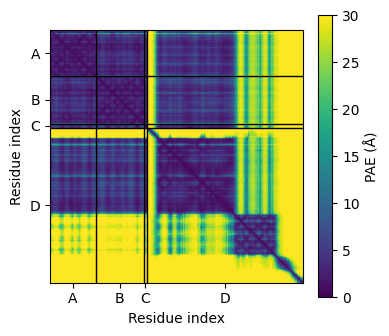

   Index   pae_col       Name  Results  ActivationScore  Sensitivity
0      1  3.580556  CDR1A_D1A       91             0.91         0.09
1      2  3.632778  CDR1A_R2A       79             0.79         0.21
2      3  3.088889  CDR1A_G3A       94             0.94         0.06
3      4  3.260000  CDR1A_S4A       96             0.96         0.04
4      5  2.840331  CDR1A_Q5A        4             0.04         0.96


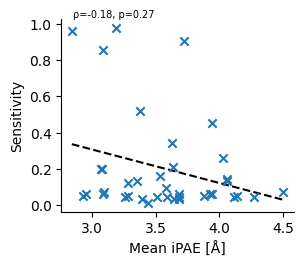

In [34]:
json_file = 'AF3_output_LLWNGPMAV_alascan/fold_alascan_llwngpmav_full_data_0.json'

df = compute_mean_tcr_pae_to_interface(
    json_file=json_file,
    mhc_groove_ranges=[(26, 200)],
    loops_A=[(27, 32), (50, 55), (90, 95)],
    loops_B=[(27, 31), (49, 54), (92, 100)],
    pae_cutoff=10,
    plot=True
)

# experimental data
df_exp = pd.read_csv('../260317_YF-modes_exp_integration_clean/YF-AlaScan.csv', sep=';')[['Name', 'Results']]
df_exp = df_exp[df_exp['Name'] != 'template']
df_exp = df_exp.reset_index(drop=True)
df_exp['ActivationScore'] = df_exp['Results'] / 100
df_exp['ActivationScore'] = df_exp['ActivationScore'].clip(0, 1)
df_exp['Sensitivity'] = 1 - df_exp['ActivationScore']

df = pd.concat([df, df_exp], axis=1)
print(df.head())
### Plot correlation ###
fig, ax = plt.subplots(1, 1, figsize=(3,2.5))

# Compute Spearman correlation
rho, pval = spearmanr(df['pae_col'], df['Sensitivity'])

# Draw a smooth line showing monotonic trend
sns.regplot(x=df['pae_col'], y=df['Sensitivity'], ax=ax, scatter=False, color='black', line_kws={'lw':1.5, 'ls':'--'}, ci=False)

# Add rho to the plot
# Format string
if pval < 0.01:
    p_str = f"{pval:.1e}"   # scientific notation
else:
    p_str = f"{pval:.2f}"   # fixed-point

ax.text(
0.05, 1.05, f"ρ={rho:.2f}, p={p_str}", 
transform=ax.transAxes, fontsize=7, verticalalignment='top'
)

sns.scatterplot(df, x='pae_col', y='Sensitivity', ax=ax, legend=False, marker='x', linewidth=1.5, zorder=2)
ax.set_ylabel('Sensitivity')
ax.set_xlabel('Mean iPAE [Å]')

sns.despine()



